In [1]:
# Import library yang diperlukan
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

## load data yang telah di proses

In [2]:
df = pd.read_csv('../data/processed/data_kriminal_processed_full.csv')

## cek distribusi kelas perkara

In [3]:
print(df['PERKARA'].value_counts())

print(df['PERKARA'].value_counts(normalize=True)*100)

PERKARA
Pencurian       210
Penganiayaan     90
Penipuan         84
Perusakan        82
Narkoba          52
Name: count, dtype: int64
PERKARA
Pencurian       40.540541
Penganiayaan    17.374517
Penipuan        16.216216
Perusakan       15.830116
Narkoba         10.038610
Name: proportion, dtype: float64


Berdasarkan hasil analisis distribusi kelas, data kasus kriminal terdiri dari 8 kategori perkara. Distribusi data tidak seimbang karena jumlah data pada setiap kategori berbeda cukup signifikan. Kategori Pencurian memiliki jumlah data terbanyak sebanyak 209 dokumen, sedangkan kategori KDRT memiliki jumlah data paling sedikit sebanyak 28 dokumen.

## 1. tentukan fitur dan target

In [4]:
# Fitur dan target
X = df["MO_final_text"].fillna("")
y = df["PERKARA"]

## 2. Tentukan skenario pengujian

Skenario A

80% training
20% testing

Gunakan stratify

Karena data tidak seimbang

In [5]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Train:")
print(y_train_80.value_counts())

print("\nTest:")
print(y_test_80.value_counts())

print(y_train_80.value_counts(normalize=True)*100)
print(y_test_80.value_counts(normalize=True)*100)

Train:
PERKARA
Pencurian       168
Penganiayaan     72
Penipuan         67
Perusakan        65
Narkoba          42
Name: count, dtype: int64

Test:
PERKARA
Pencurian       42
Penganiayaan    18
Penipuan        17
Perusakan       17
Narkoba         10
Name: count, dtype: int64
PERKARA
Pencurian       40.579710
Penganiayaan    17.391304
Penipuan        16.183575
Perusakan       15.700483
Narkoba         10.144928
Name: proportion, dtype: float64
PERKARA
Pencurian       40.384615
Penganiayaan    17.307692
Penipuan        16.346154
Perusakan       16.346154
Narkoba          9.615385
Name: proportion, dtype: float64


Skenario B

70% training
30% testing

Gunakan stratify

Karena data tidak seimbang

In [7]:
# X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
#     X,
#     y,
#     test_size=0.3,
#     random_state=42,
#     stratify=y
# )

In [8]:
# print("Train:")
# print(y_train_70.value_counts())

# print("\nTest:")
# print(y_test_70.value_counts())

# print(y_train_70.value_counts(normalize=True)*100)
# print(y_test_70.value_counts(normalize=True)*100)

Pembagian data dilakukan menggunakan metode stratified sampling untuk menjaga proporsi setiap kelas pada data pelatihan dan data pengujian. Hasil pembagian menunjukkan bahwa distribusi kelas pada data training dan testing tetap mendekati distribusi data asli sehingga dapat mengurangi bias pada proses pelatihan dan evaluasi model.

## TF-IDF
### Untuk skenario 80:20

In [9]:
tfidf = TfidfVectorizer()

X_train_80_tfidf = tfidf.fit_transform(X_train_80)
X_test_80_tfidf = tfidf.transform(X_test_80)

print("Train Shape :", X_train_80_tfidf.shape)
print("Test Shape  :", X_test_80_tfidf.shape)

print("Jumlah fitur :", len(tfidf.get_feature_names_out()))

Train Shape : (414, 905)
Test Shape  : (104, 905)
Jumlah fitur : 905


cek isi kamus kata

In [10]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['acak' 'acara' 'acer' 'ada' 'admin' 'administrasi' 'adu' 'agen' 'air'
 'ajak' 'akar' 'aki' 'akibat' 'akses' 'aksi' 'aktif' 'aku' 'akun' 'alami'
 'alas' 'alat' 'aman' 'amat' 'ambil' 'ambulans' 'anak' 'ancam' 'anggap'
 'anggota' 'aniaya' 'anjing' 'antre' 'antri' 'aparat' 'aplikasi' 'apm'
 'arah' 'arisan' 'asbak' 'asin' 'asmara' 'aspal' 'asuransi' 'asus' 'atap'
 'atas' 'awat' 'ayam' 'bagi' 'bak']


cek kata yang paling sering muncul

pertimbangkan kata yang tidak mewakili kasus kejahatan

In [11]:
tfidf_doc_df = pd.DataFrame(
    X_train_80_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

mean_tfidf = tfidf_doc_df.mean().sort_values(ascending=False)

print(mean_tfidf.head(20))

pelaku    0.083102
korban    0.083033
ambil     0.050072
motor     0.041298
rumah     0.041281
milik     0.035014
rusak     0.033919
sungai    0.033076
kunci     0.032345
uang      0.031996
pintu     0.027674
masuk     0.027407
sepeda    0.025876
unit      0.024549
parkir    0.024282
pukul     0.024145
pinyuh    0.022775
lapor     0.022728
rupiah    0.022491
kosong    0.022058
dtype: float64


Hasil ekstraksi fitur menggunakan TF-IDF menghasilkan 1015 fitur kata. Kata-kata dengan bobot rata-rata TF-IDF tertinggi menunjukkan istilah yang paling representatif dalam kumpulan dokumen kasus kriminal.

In [12]:
# feature_names = tfidf.get_feature_names_out()

# print("Jumlah fitur:", len(feature_names))

# print("50 fitur pertama:")
# print(feature_names[:50])

# print("\nRata-rata TF-IDF untuk setiap fitur:")
# print(mean_tfidf.head(50))

## cek kelas kasus kriminal

In [13]:
kelas_docs = (
    df.groupby('PERKARA')['MO_final_text']
      .apply(lambda x: ' '.join(x))
)

kelas_docs

PERKARA
Narkoba         petugas curiga gerak gerik pelaku pinggir jala...
Pencurian       pelaku pura pura tamu pembeli korban lengah pe...
Penganiayaan    pelaku singgung tatap korban papas jalan pukul...
Penipuan        pelaku tawar sepeda motor lelang korban harga ...
Perusakan       pelaku rusak halaman korban akibat sengketa ta...
Name: MO_final_text, dtype: object

In [14]:
tfidf_kelas = TfidfVectorizer()

X_kelas = tfidf_kelas.fit_transform(kelas_docs)

feature_names = tfidf_kelas.get_feature_names_out()

In [15]:
tfidf_class_df = pd.DataFrame(
    X_kelas.toarray(),
    index=kelas_docs.index,
    columns=feature_names
)

tfidf_class_df.head()

,acak,acara,acer,ada,admin,administrasi,adu,agen,air,ajak,...,web,website,whatsapp,wifi,wilayah,wisata,xiaomi,yamaha,yolandari,zona
PERKARA,,,,,,,,,,,,,,,,,,,,,
Narkoba,0.00000,0.00000,0.000000,0.011525,0.000000,0.000000,0.000000,0.000000,0.007718,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Pencurian,0.03616,0.00000,0.021696,0.000000,0.000000,0.000000,0.000000,0.000000,0.026639,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007232,0.061472,0.003616,0.000000
Penganiayaan,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.077551,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Penipuan,0.00000,0.00000,0.000000,0.000000,0.009621,0.009621,0.000000,0.009621,0.000000,0.038483,...,0.009621,0.009621,0.009621,0.000000,0.000000,0.009621,0.000000,0.000000,0.000000,0.000000
Perusakan,0.00000,0.02403,0.000000,0.000000,0.000000,0.000000,0.019388,0.000000,0.016093,0.000000,...,0.000000,0.000000,0.000000,0.012015,0.012015,0.000000,0.000000,0.000000,0.000000,0.012015


kata yang membedakan setiap perkara.

## top kata setiap kasus PERKARA

In [16]:
for perkara in tfidf_class_df.index:

    top_words = tfidf_class_df.loc[perkara] \
        .sort_values(ascending=False) \
        .head(10)

    print(f"\n=== {perkara} ===")
    print(top_words)


=== Narkoba ===
sungai     0.344026
petugas    0.306834
sabu       0.299641
pinyuh     0.232450
temu       0.232450
pelaku     0.230645
camat      0.204556
geledah    0.172870
gerebek    0.172870
warga      0.162082
Name: Narkoba, dtype: float64

=== Pencurian ===
ambil     0.446359
pelaku    0.353226
kunci     0.277151
korban    0.266873
sungai    0.221721
unit      0.206113
rusak     0.169208
motor     0.165413
masuk     0.157410
pinyuh    0.154621
Name: Pencurian, dtype: float64

=== Penganiayaan ===
korban    0.649848
pelaku    0.399736
pukul     0.245794
aniaya    0.209723
wajah     0.174769
mulut     0.169203
kali      0.148053
emosi     0.141003
tangan    0.123077
kosong    0.122897
Name: Penganiayaan, dtype: float64

=== Penipuan ===
pelaku      0.453845
korban      0.417349
uang        0.309267
janji       0.240517
tawar       0.221275
transfer    0.221275
rupiah      0.186285
murah       0.173172
kirim       0.153931
harga       0.147476
Name: Penipuan, dtype: float64

=== P

In [17]:
selected_words = set()

for perkara in tfidf_class_df.index:
    top_words = tfidf_class_df.loc[perkara] \
        .sort_values(ascending=False) \
        .head(5)

    selected_words.update(top_words.index)

selected_words = list(selected_words)

## heatmap perkara dan kata yang terdapat pada 5 data pertama

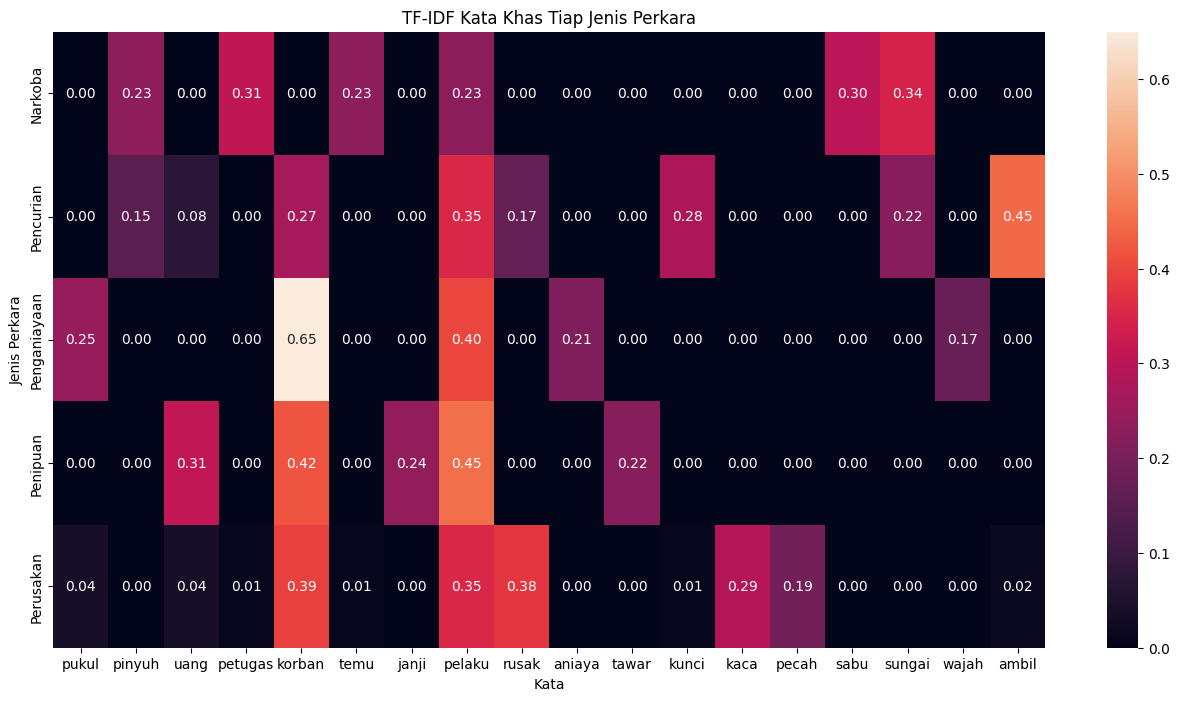

In [18]:
heatmap_df_2 = tfidf_class_df[selected_words]

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_df_2,
    annot=True,
    fmt=".2f"
)

plt.title("TF-IDF Kata Khas Tiap Jenis Perkara")
plt.ylabel("Jenis Perkara")
plt.xlabel("Kata")

plt.show()